# Анализ тональности текстов с использованием нейронных сетей

## Цель работы
В этой работе мы будем решать задачу классификации тональности текстовых отзывов на русском языке. Рассмотрим:
- **Бинарную классификацию** (позитивные/негативные отзывы)
- **Применение техник регуляризации** (Dropout и Early Stopping)
- **Мультиклассовую классификацию** (позитивные/негативные/нейтральные)
- **Сравнение различных архитектур** нейронных сетей

## Используемые технологии
- **TF-IDF** для векторизации текста
- **TensorFlow/Keras** для построения нейронных сетей
- **scikit-learn** для предобработки и метрик

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Настройка отображения
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

## Подготовка данных

Создаём датасет с отзывами на русском языке. Каждый отзыв имеет метку тональности:
- **1** — позитивный отзыв
- **0** — негативный отзыв
- **2** — нейтральный отзыв

In [2]:
# Данные для анализа тональности
sentiment_data = {
    "text": [
        # --- позитив (1) ---
        "Отличный фильм, очень понравился!",
        "Прекрасная книга, рекомендую всем прочитать.",
        "Качественный товар, доволен покупкой.",
        "Замечательный сервис, быстро и профессионально.",
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",
        "Великолепный спектакль, получил массу удовольствия.",
        "Отличное приложение, удобный интерфейс.",
        "Прекрасный отель, комфортные номера и хороший завтрак.",
        "Замечательный преподаватель, интересные лекции.",
        "Потрясающая музыка, слушаю постоянно.",
        "Отличный телефон, все работает быстро.",
        "Прекрасный подарок, очень доволен.",
        "Качественный кофе, ароматный и вкусный.",
        "Замечательный парк, красивая природа.",
        "Потрясающий концерт, незабываемые эмоции.",
        # --- негатив (0) ---
        "Ужасный фильм, полная потеря времени.",
        "Плохая книга, скучно и неинтересно.",
        "Низкое качество товара, очень разочарован.",
        "Плохой сервис, долго ждал и ничего не получил.",
        "Отвратительный ресторан, невкусная еда.",
        "Скучный спектакль, не рекомендую.",
        "Плохое приложение, постоянно глючит.",
        "Ужасный отель, грязные номера и плохое обслуживание.",
        "Скучный преподаватель, неинтересные лекции.",
        "Плохая музыка, не понравилась.",
        "Плохой телефон, постоянно зависает.",
        "Разочаровался в подарке, не то что ожидал.",
        "Плохой кофе, безвкусный и холодный.",
        "Запущенный парк, грязно и неухоженно.",
        "Скучный концерт, не оправдал ожиданий.",
        # --- нейтрал (2) ---
        "Обычный фильм, ничего особенного.",
        "Стандартная книга, читается нормально.",
        "Обычный товар, соответствует описанию.",
        "Нормальный сервис, без особых претензий.",
        "Обычный ресторан, стандартное меню.",
        "Средний спектакль, можно посмотреть.",
        "Обычное приложение, работает как надо.",
        "Стандартный отель, без изысков.",
        "Обычный преподаватель, стандартные лекции.",
        "Средняя музыка, ничего особенного.",
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
    ]
}

df = pd.DataFrame(sentiment_data)
print("Всего отзывов:", len(df))
print("\nРаспределение классов:")
print(df["sentiment"].value_counts().sort_index())
print("\nПримеры отзывов:")
print(df.head(3))

Всего отзывов: 40

Распределение классов:
sentiment
0    15
1    15
2    10
Name: count, dtype: int64

Примеры отзывов:
                                           text  sentiment
0             Отличный фильм, очень понравился!          1
1  Прекрасная книга, рекомендую всем прочитать.          1
2         Качественный товар, доволен покупкой.          1


---
## Задание 1: Бинарная классификация

### Описание
Построим базовую модель для классификации отзывов на **позитивные (1)** и **негативные (0)**. Нейтральные отзывы исключаем.

### Этапы:
1. Фильтрация данных (убираем класс 2)
2. Векторизация текста через TF-IDF
3. Нормализация признаков
4. Обучение полносвязной нейронной сети
5. Оценка качества

In [3]:
print("=" * 50)
print("ЗАДАНИЕ 1: БИНАРНАЯ КЛАССИФИКАЦИЯ")
print("=" * 50)

# Отфильтровываем нейтральные отзывы
df_binary = df[df["sentiment"] != 2]
print(f"Данные для бинарной классификации: {len(df_binary)} отзывов")

# Векторизация текста с помощью TF-IDF
# max_features=100 — берём только 100 наиболее значимых слов
vectorizer = TfidfVectorizer(max_features=100)
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["sentiment"].values

print(f"Размерность признакового пространства: {X.shape}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Нормализация (приведение к среднему 0 и стандартному отклонению 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ЗАДАНИЕ 1: БИНАРНАЯ КЛАССИФИКАЦИЯ
Данные для бинарной классификации: 30 отзывов
Размерность признакового пространства: (30, 96)
Train: 21, Test: 9


In [4]:
# Построение модели
# Архитектура: 100 -> 32 -> 16 -> 1
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),  # sigmoid для бинарной классификации
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",  # функция потерь для бинарной классификации
    metrics=["accuracy"]
)

print("Архитектура модели:")
model.summary()

Архитектура модели:


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Обучение модели
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=8,
    validation_split=0.2,  # 20% от train используется для валидации
    verbose=1
)

Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - accuracy: 0.3750 - loss: 0.8265 - val_accuracy: 0.8000 - val_loss: 0.5642
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4375 - loss: 0.7777 - val_accuracy: 0.8000 - val_loss: 0.5717
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4375 - loss: 0.7401 - val_accuracy: 0.8000 - val_loss: 0.5787
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.7020 - val_accuracy: 0.8000 - val_loss: 0.5842
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.6704 - val_accuracy: 0.8000 - val_loss: 0.5901
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6875 - loss: 0.6434 - val_accuracy: 0.8000 - val_loss: 0.5960
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7500 - loss: 0.6168 - val_accuracy: 0.8000 - val_loss: 0.6023
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8125 - loss: 0.5912 - val_accuracy: 0.8000 - val_loss: 0.6083

In [6]:
# Предсказание и оценка качества
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ")
print("=" * 50)
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ
F1-Score:  0.6667
Precision: 0.5000
Recall:    1.0000


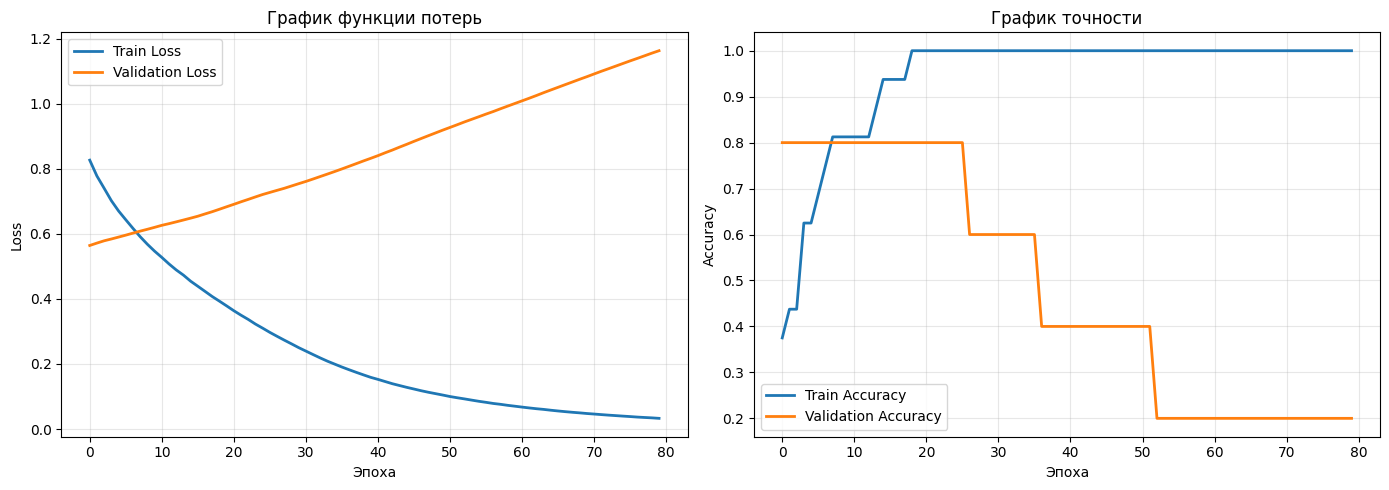

In [7]:
# Визуализация обучения
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Описание графиков (Задание 1)

**График функции потерь (Loss):**
- Показывает изменение ошибки модели в процессе обучения
- **Train Loss** (синяя линия) — ошибка на обучающей выборке
- **Validation Loss** (оранжевая линия) — ошибка на валидационной выборке
- **Что смотреть:** Обе кривые должны снижаться. Если val_loss начинает расти, а train_loss падает — это признак переобучения

**График точности (Accuracy):**
- Отражает долю правильных предсказаний
- **Train Accuracy** — точность на обучающих данных
- **Validation Accuracy** — точность на валидационных данных
- **Что смотреть:** Обе кривые должны расти. Большой разрыв между ними указывает на переобучение

**Выводы:**
- Опишите, как ведут себя кривые на ваших графиках
- Есть ли признаки переобучения?
- Достигла ли модель стабильной производительности?

---
## Задание 2: Применение Dropout и Early Stopping

### Описание
Улучшаем модель, добавляя техники регуляризации:
- **Dropout** — случайное отключение нейронов во время обучения для предотвращения переобучения
- **Early Stopping** — остановка обучения при отсутствии улучшений на валидации

### Ожидаемый результат:
- Снижение переобучения
- Более стабильные предсказания
- Оптимальное количество эпох

In [8]:
print("=" * 50)
print("ЗАДАНИЕ 2: МОДЕЛЬ С DROPOUT И EARLY STOPPING")
print("=" * 50)

# Новая модель с Dropout
model2 = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Отключаем 30% нейронов
    Dense(16, activation="relu"),
    Dropout(0.2),  # Отключаем 20% нейронов
    Dense(1, activation="sigmoid"),
])

model2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callback для ранней остановки
early_stop = EarlyStopping(
    monitor="val_loss",           # Отслеживаем val_loss
    patience=15,                   # Ждём 15 эпох без улучшений
    restore_best_weights=True      # Восстанавливаем лучшие веса
)

print("Модель с регуляризацией:")
model2.summary()

ЗАДАНИЕ 2: МОДЕЛЬ С DROPOUT И EARLY STOPPING
Модель с регуляризацией:


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Обучение с Early Stopping
history2 = model2.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nОбучение остановилось на эпохе: {len(history2.history['loss'])}")

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5625 - loss: 0.7122 - val_accuracy: 0.2000 - val_loss: 0.9646
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5625 - loss: 0.7561 - val_accuracy: 0.2000 - val_loss: 0.9657
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4375 - loss: 0.7185 - val_accuracy: 0.2000 - val_loss: 0.9691
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 0.5989 - val_accuracy: 0.2000 - val_loss: 0.9732
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5625 - loss: 0.6914 - val_accuracy: 0.2000 - val_loss: 0.9757
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6482 - val_accuracy: 0.2000 - val_loss: 0.9801
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6875 - loss: 0.5630 - val_accuracy: 0.2000 - val_loss: 0.9857
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5625 - loss: 0.6617 - val_accuracy: 0.2000 - val_loss

In [10]:
# Оценка качества
y_pred2 = (model2.predict(X_test) > 0.5).astype(int).flatten()

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ С DROPOUT И EARLY STOPPING")
print("=" * 50)
print(f"F1-Score:  {f1_score(y_test, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred2):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred2):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

РЕЗУЛЬТАТЫ С DROPOUT И EARLY STOPPING
F1-Score:  0.4000
Precision: 0.2857
Recall:    0.6667


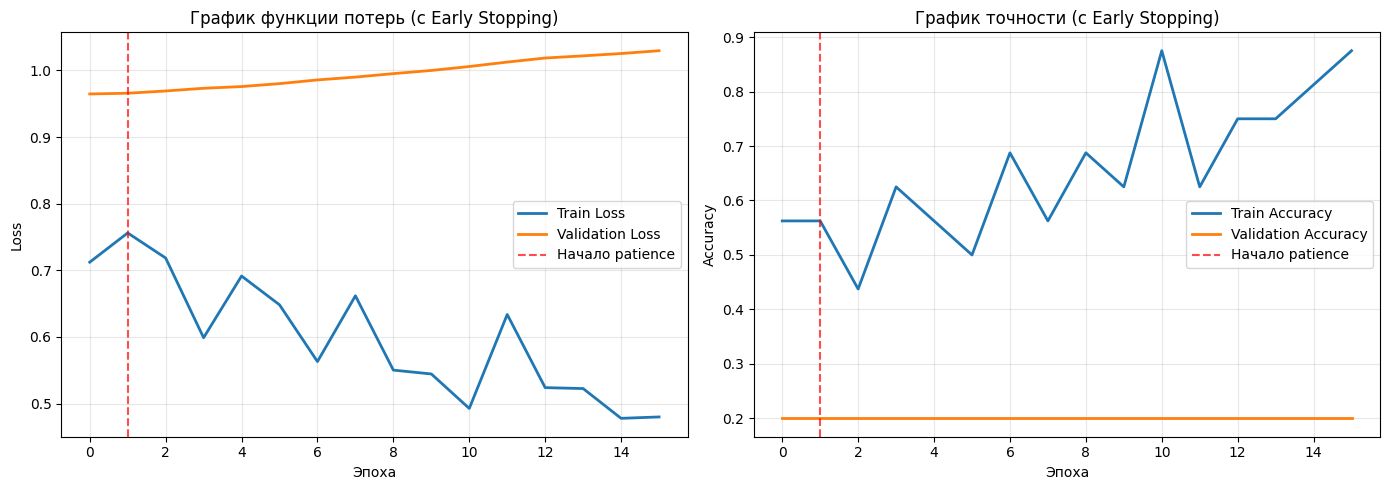

In [11]:
# Визуализация обучения
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history2.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history2.history["val_loss"], label="Validation Loss", linewidth=2)
plt.axvline(x=len(history2.history['loss'])-15, color='red', linestyle='--', 
            label='Начало patience', alpha=0.7)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь (с Early Stopping)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history2.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history2.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.axvline(x=len(history2.history['loss'])-15, color='red', linestyle='--', 
            label='Начало patience', alpha=0.7)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности (с Early Stopping)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Задание 3: Мультиклассовая классификация

### Описание
Теперь классифицируем отзывы на **три класса**:
- **0** — негативные
- **1** — позитивные
- **2** — нейтральные

### Изменения в архитектуре:
- Выходной слой: 3 нейрона с активацией **softmax**
- Функция потерь: **sparse_categorical_crossentropy**
- Метрики: weighted average (учёт дисбаланса классов)

In [12]:
print("=" * 50)
print("ЗАДАНИЕ 3: МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ")
print("=" * 50)

# Используем все данные (включая нейтральные)
X_all = vectorizer.fit_transform(df["text"]).toarray()
y_all = df["sentiment"].values

print(f"Всего данных: {len(X_all)}")
print(f"Распределение классов:\n{pd.Series(y_all).value_counts().sort_index()}")

# Разделение на train/test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_all, y_all, test_size=0.3, random_state=42
)

# Нормализация
scaler2 = StandardScaler()
X_train_m = scaler2.fit_transform(X_train_m)
X_test_m = scaler2.transform(X_test_m)

print(f"Train: {len(X_train_m)}, Test: {len(X_test_m)}")

ЗАДАНИЕ 3: МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ
Всего данных: 40
Распределение классов:
0    15
1    15
2    10
Name: count, dtype: int64
Train: 28, Test: 12


In [13]:
# Модель для мультиклассовой классификации
model3 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_m.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax"),  # 3 класса, softmax для вероятностей
])

model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # для целочисленных меток
    metrics=["accuracy"]
)

print("Архитектура модели:")
model3.summary()

Архитектура модели:


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,643 (33.76 KB)

 Trainable params: 8,643 (33.76 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Обучение
history3 = model3.fit(
    X_train_m, y_train_m,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.2273 - loss: 1.9978 - val_accuracy: 0.3333 - val_loss: 1.3906
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2727 - loss: 1.8114 - val_accuracy: 0.3333 - val_loss: 1.3754
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1818 - loss: 1.7919 - val_accuracy: 0.3333 - val_loss: 1.3672
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1818 - loss: 1.4872 - val_accuracy: 0.3333 - val_loss: 1.3630
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3636 - loss: 1.3081 - val_accuracy: 0.1667 - val_loss: 1.3624
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 1.0981 - val_accuracy: 0.1667 - val_loss: 1.3654
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4545 - loss: 1.0654 - val_accuracy: 0.0000e+00 - val_loss: 1.3699
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3636 - loss: 1.0448 - val_accuracy: 0.1667 - val_l

In [15]:
# Предсказание (выбираем класс с максимальной вероятностью)
y_pred_m = np.argmax(model3.predict(X_test_m), axis=1)

print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ МУЛЬТИКЛАССОВОЙ КЛАССИФИКАЦИИ")
print("=" * 50)
print(f"F1-Score (weighted):  {f1_score(y_test_m, y_pred_m, average='weighted'):.4f}")
print(f"Precision (weighted): {precision_score(y_test_m, y_pred_m, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test_m, y_pred_m, average='weighted'):.4f}")

# Детальная информация по классам
print("\nF1-Score по классам:")
for i, score in enumerate(f1_score(y_test_m, y_pred_m, average=None)):
    class_name = ["Негативный", "Позитивный", "Нейтральный"][i]
    print(f"  Класс {i} ({class_name}): {score:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

РЕЗУЛЬТАТЫ МУЛЬТИКЛАССОВОЙ КЛАССИФИКАЦИИ
F1-Score (weighted):  0.1619
Precision (weighted): 0.1528
Recall (weighted):    0.2500

F1-Score по классам:
  Класс 0 (Негативный): 0.0000
  Класс 1 (Позитивный): 0.2857
  Класс 2 (Нейтральный): 0.4000


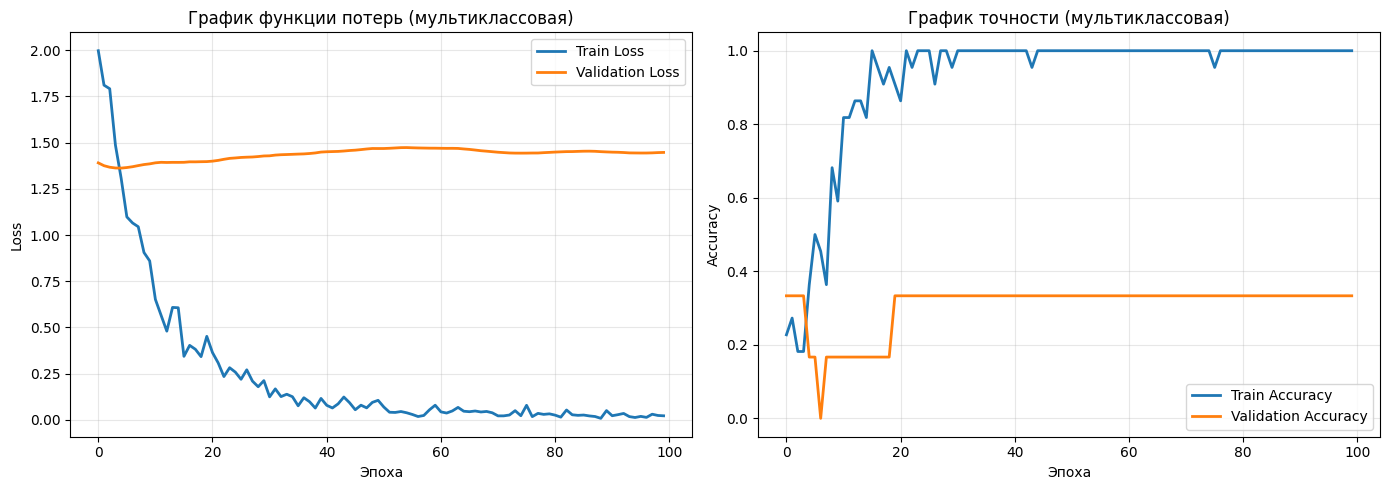

In [16]:
# Визуализация обучения
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history3.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history3.history["val_loss"], label="Validation Loss", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График функции потерь (мультиклассовая)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history3.history["accuracy"], label="Train Accuracy", linewidth=2)
plt.plot(history3.history["val_accuracy"], label="Validation Accuracy", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("График точности (мультиклассовая)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Задание 4: Сравнение различных архитектур

### Описание
Исследуем влияние глубины нейронной сети на качество бинарной классификации.

### Тестируемые архитектуры:
1. **16** — одно скрытое слоя (16 нейронов)
2. **32-16** — два слоя (32 → 16)
3. **64-32-16** — три слоя (64 → 32 → 16)
4. **128-64-32-16** — четыре слоя (128 → 64 → 32 → 16)

### Гипотеза:
Более глубокие сети могут лучше выявлять сложные паттерны, но также подвержены переобучению на малых датасетах.

In [17]:
print("=" * 50)
print("ЗАДАНИЕ 4: СРАВНЕНИЕ АРХИТЕКТУР")
print("=" * 50)

# Конфигурации для тестирования
configs = {
    "16": [16],
    "32-16": [32, 16],
    "64-32-16": [64, 32, 16],
    "128-64-32-16": [128, 64, 32, 16],
}

results = []

for name, layers_list in configs.items():
    print(f"\nОбучение архитектуры: {name}")
    print("-" * 30)
    
    # Создание модели
    m = Sequential()
    m.add(Dense(layers_list[0], activation="relu", input_shape=(X_train.shape[1],)))
    
    for size in layers_list[1:]:
        m.add(Dense(size, activation="relu"))
    
    m.add(Dense(1, activation="sigmoid"))
    
    # Компиляция и обучение
    m.compile(optimizer="adam", loss="binary_crossentropy")
    m.fit(X_train, y_train, epochs=80, batch_size=8, verbose=0)
    
    # Предсказание
    y_pred_a = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    
    # Сохранение результатов
    results.append({
        "Архитектура": name,
        "F1": round(f1_score(y_test, y_pred_a), 4),
        "Precision": round(precision_score(y_test, y_pred_a), 4),
        "Recall": round(recall_score(y_test, y_pred_a), 4),
    })
    
    print(f"F1: {results[-1]['F1']}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 50)
print(results_df.to_string(index=False))

ЗАДАНИЕ 4: СРАВНЕНИЕ АРХИТЕКТУР

Обучение архитектуры: 16
------------------------------


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.8571

Обучение архитектуры: 32-16
------------------------------


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.5

Обучение архитектуры: 64-32-16
------------------------------


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.5714

Обучение архитектуры: 128-64-32-16
------------------------------


C:\Users\danii\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.5

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
 Архитектура     F1  Precision  Recall
          16 0.8571       0.75  1.0000
       32-16 0.5000       0.40  0.6667
    64-32-16 0.5714       0.50  0.6667
128-64-32-16 0.5000       0.40  0.6667


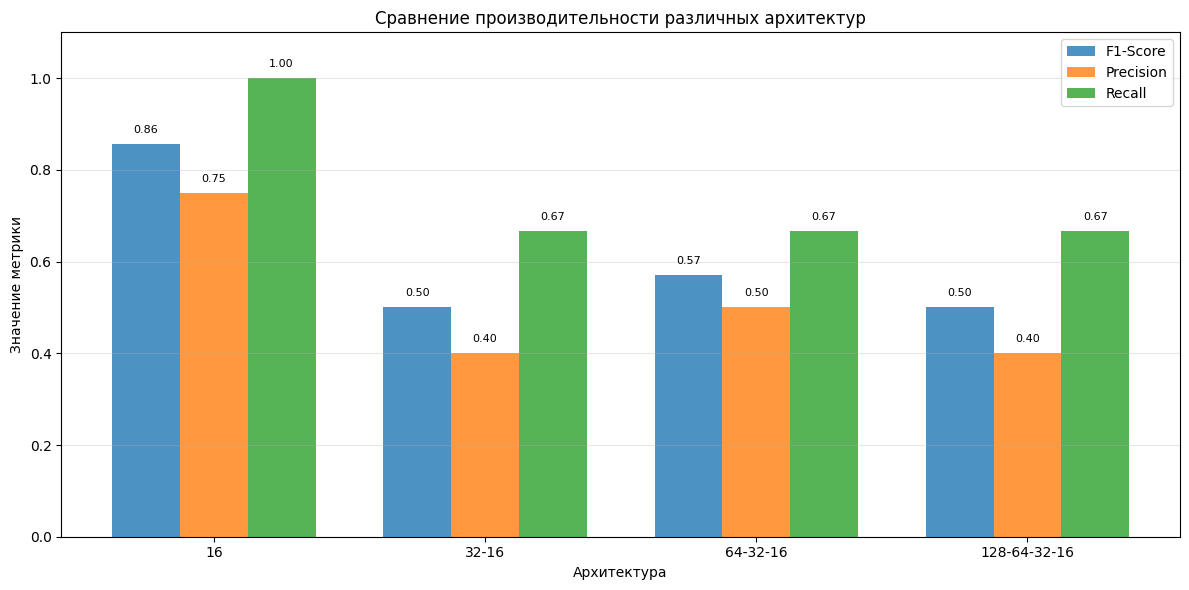


ЛУЧШАЯ АРХИТЕКТУРА: 16
   F1-Score: 0.8571


In [19]:
# Визуализация сравнения
plt.figure(figsize=(12, 6))

x = range(len(results_df))
width = 0.25

plt.bar([i - width for i in x], results_df["F1"], width, label="F1-Score", alpha=0.8)
plt.bar([i for i in x], results_df["Precision"], width, label="Precision", alpha=0.8)
plt.bar([i + width for i in x], results_df["Recall"], width, label="Recall", alpha=0.8)

plt.xlabel("Архитектура")
plt.ylabel("Значение метрики")
plt.title("Сравнение производительности различных архитектур")
plt.xticks(x, results_df["Архитектура"])
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for i, row in results_df.iterrows():
    plt.text(i - width, row['F1'] + 0.02, f"{row['F1']:.2f}", 
             ha='center', va='bottom', fontsize=8)
    plt.text(i, row['Precision'] + 0.02, f"{row['Precision']:.2f}", 
             ha='center', va='bottom', fontsize=8)
    plt.text(i + width, row['Recall'] + 0.02, f"{row['Recall']:.2f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Определение лучшей архитектуры
best_arch = results_df.iloc[results_df["F1"].idxmax()]["Архитектура"]
best_f1 = results_df["F1"].max()

print("\n" + "=" * 50)
print(f"ЛУЧШАЯ АРХИТЕКТУРА: {best_arch}")
print(f"   F1-Score: {best_f1}")
print("=" * 50)